In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import optuna

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


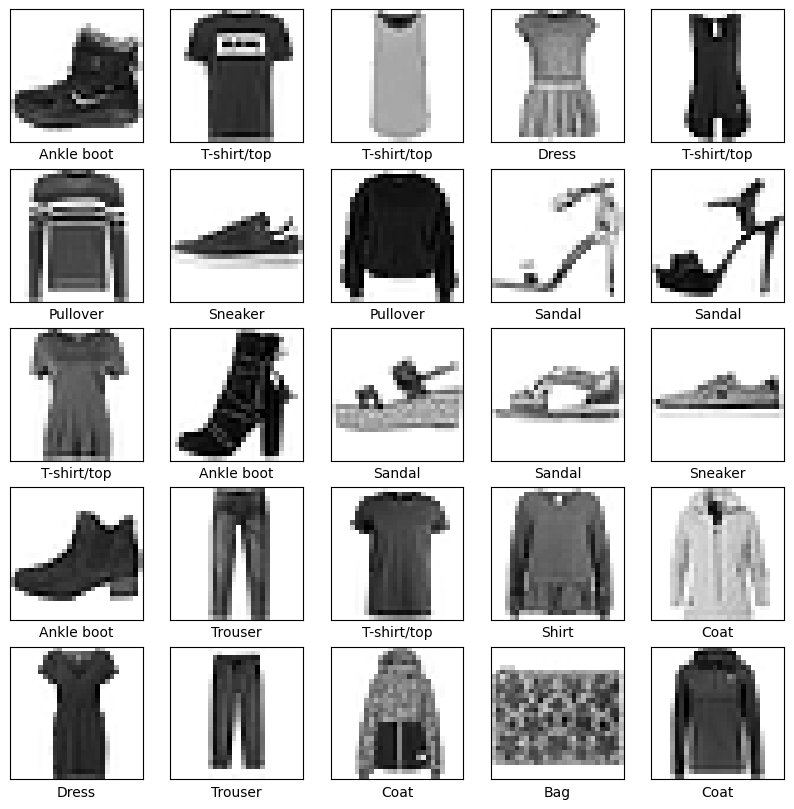

In [3]:
# visualizing the fashion data
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [4]:
# normalize and reshape
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [5]:
# create validation set
X_val = X_train[-10000:]
y_val = y_train[-10000:]

X_train_small = X_train[:-10000]
y_train_small = y_train[:-10000]

print("Training shape:", X_train_small.shape)
print("Validation shape:", X_val.shape)

Training shape: (50000, 28, 28)
Validation shape: (10000, 28, 28)


In [6]:
# keep track of results + function to plot training history
results = []

def plot_history(history, title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


def evaluate_model(model, history, model_name):

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Model": model_name,
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    })

    print(model_name)
    print("Test Accuracy:", round(test_acc,4))
    print("Test Loss:", round(test_loss,4))

    plot_history(history, model_name)

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.8262 - loss: 1.0946 - val_accuracy: 0.8715 - val_loss: 0.3788
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8873 - loss: 0.3249 - val_accuracy: 0.8831 - val_loss: 0.3393
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9005 - loss: 0.2765 - val_accuracy: 0.8910 - val_loss: 0.3141
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9083 - loss: 0.2511 - val_accuracy: 0.8906 - val_loss: 0.3195
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9156 - loss: 0.2288 - val_accuracy: 0.8901 - val_loss: 0.3290
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9224 - loss: 0.2117 - val_accuracy: 0.8937 - val_loss: 0.3230
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9276 - loss: 0.1947 - val_accuracy: 0.8910 - val_loss: 0.3490
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9324 -

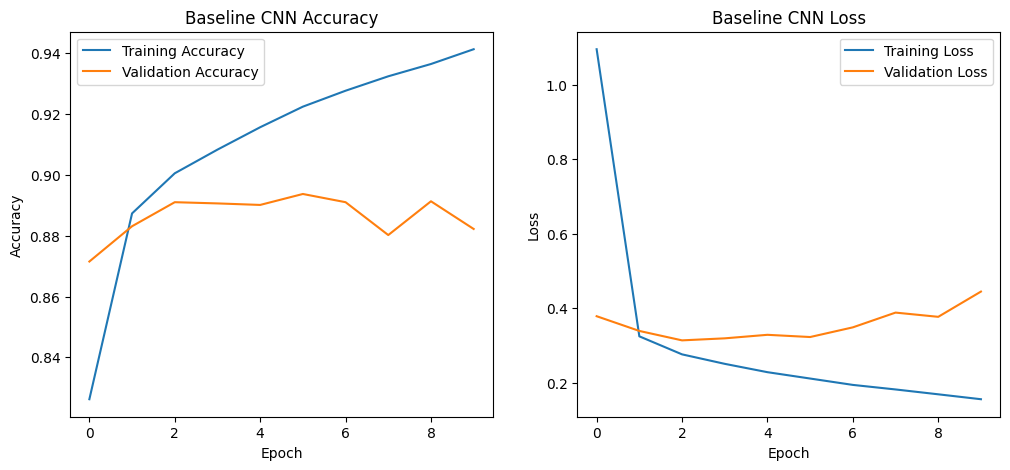

In [7]:
# start building baseline cnn
baseline_model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

evaluate_model(
    baseline_model,
    baseline_history,
    "Baseline CNN"
)

iteration 1: deeper

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8070 - loss: 0.6628 - val_accuracy: 0.8488 - val_loss: 0.4111
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8673 - loss: 0.3630 - val_accuracy: 0.8673 - val_loss: 0.3555
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8818 - loss: 0.3229 - val_accuracy: 0.8756 - val_loss: 0.3448
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8934 - loss: 0.2925 - val_accuracy: 0.8886 - val_loss: 0.3099
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8991 - loss: 0.2720 - val_accuracy: 0.8939 - val_loss: 0.2989
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9073 - loss: 0.2509 - val_accuracy: 0.8914 - val_loss: 0.3034
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9119 - loss: 0.2378 - val_accuracy: 0.8887 - val_loss: 0.3257
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9165 - loss: 0.2254 

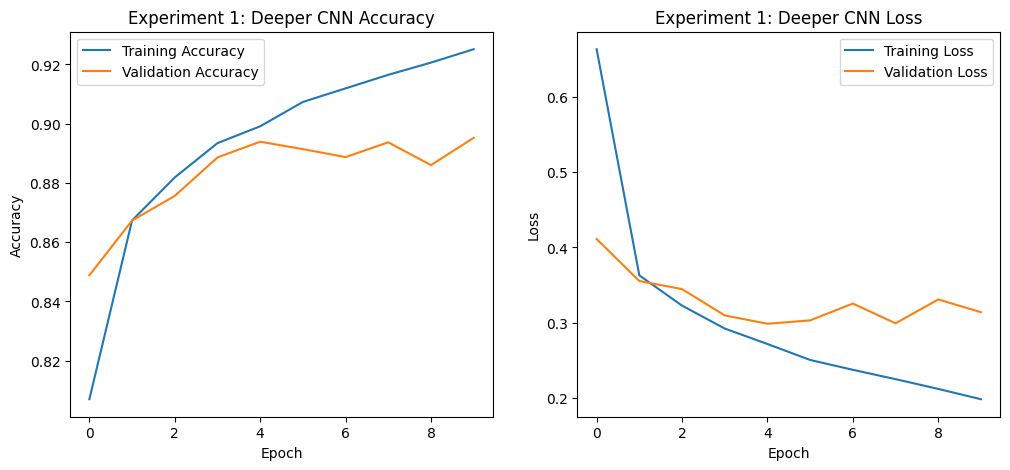

In [8]:
model_1 = models.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

evaluate_model(
    model_1,
    history_1,
    "Experiment 1: Deeper CNN"
)

iteration 2: dropout

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7319 - loss: 0.8630 - val_accuracy: 0.8496 - val_loss: 0.4335
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8261 - loss: 0.4831 - val_accuracy: 0.8643 - val_loss: 0.3788
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8492 - loss: 0.4198 - val_accuracy: 0.8628 - val_loss: 0.3714
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8608 - loss: 0.3823 - val_accuracy: 0.8752 - val_loss: 0.3387
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8693 - loss: 0.3599 - val_accuracy: 0.8829 - val_loss: 0.3209
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8751 - loss: 0.3417 - val_accuracy: 0.8815 - val_loss: 0.3153
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8850 - loss: 0.3188 - val_accuracy: 0.8955 - val_loss: 0.2931
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8863 - loss: 0.3

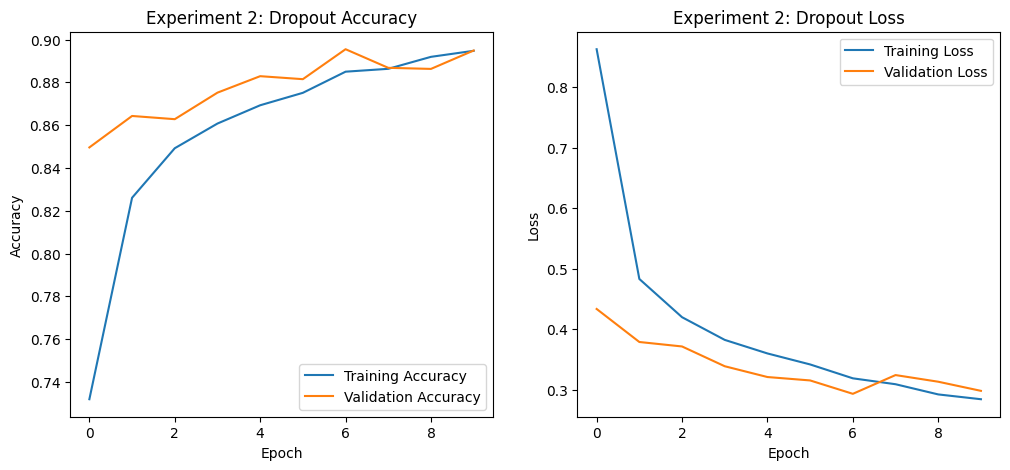

In [9]:
model_2 = models.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

evaluate_model(
    model_2,
    history_2,
    "Experiment 2: Dropout"
)

iteration 3: early stopping

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7884 - loss: 0.7649 - val_accuracy: 0.8527 - val_loss: 0.3962
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8526 - loss: 0.4015 - val_accuracy: 0.8729 - val_loss: 0.3475
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8689 - loss: 0.3555 - val_accuracy: 0.8830 - val_loss: 0.3131
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8794 - loss: 0.3243 - val_accuracy: 0.8837 - val_loss: 0.3135
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8891 - loss: 0.2980 - val_accuracy: 0.8891 - val_loss: 0.3009
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8917 - loss: 0.2880 - val_accuracy: 0.8846 - val_loss: 0.3196
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8976 - loss: 0.2767 - val_accuracy: 0.8876 - val_loss: 0.3092
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9031 - loss: 0

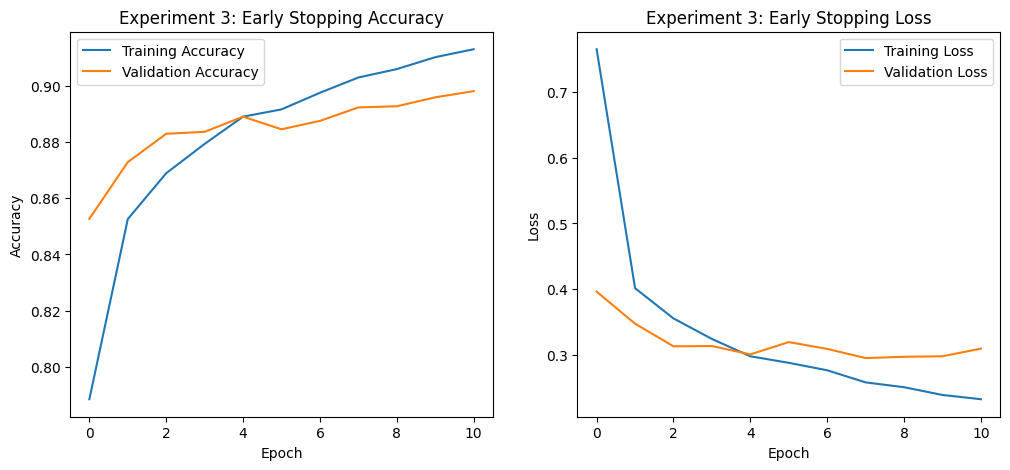

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_3 = models.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

evaluate_model(
    model_3,
    history_3,
    "Experiment 3: Early Stopping"
)

In [11]:
pd.DataFrame(results)

,Model,Best Validation Accuracy,Test Accuracy,Test Loss
0,Baseline CNN,0.8937,0.8776,0.460286
1,Experiment 1: Deeper CNN,0.8952,0.8863,0.346057
2,Experiment 2: Dropout,0.8955,0.8877,0.334078
3,Experiment 3: Early Stopping,0.8982,0.8881,0.318512


### Experiment Results before tuning

The baseline CNN used one convolutional layer followed by max pooling and a dense layer. This model achieved about **87.8%** test accuracy. The training and validation curves showed that the model learned useful image features quickly, but performance eventually plateaued.

- Iteration 1 changed one factor by adding a second convolutional layer. This deeper CNN improved test accuracy to about 88.6%. The additional convolutional layer helped the model learn more detailed image patterns and improved validation performance compared to the baseline model.

- Iteration 2 added dropout regularization while keeping the deeper CNN structure. The purpose of dropout was to reduce overfitting by randomly disabling neurons during training. This model achieved about 88.8% test accuracy and slightly improved validation stability compared to Experiment 1.

- **Iteration 3** added early stopping along with a larger dense layer and dropout. Early stopping monitored validation loss and restored the best weights once validation performance stopped improving. This model achieved about 88.8% test accuracy and the lowest validation loss among the manually tested experiments. The training and validation curves showed more stable learning behavior and reduced overfitting compared to earlier models.

This experimentation showed that increasing model complexity can improve performance, but larger models also eventually require additional regularization to maintain stable validation behavior.

optuna tuning for best final model

In [12]:
def objective(trial):

    filters = trial.suggest_categorical("filters", [32])
    dense_units = trial.suggest_categorical("dense_units", [64, 128])
    dropout_rate = trial.suggest_categorical("dropout_rate", [0.2, 0.3, 0.4])
    learning_rate = trial.suggest_float("learning_rate", 0.0001, 0.01, log=True)

    model = models.Sequential([

        layers.Conv2D(filters, (3,3), activation="relu", input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*2, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_small,
        y_train_small,
        validation_data=(X_val, y_val),
        epochs=8,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    return max(history.history["val_accuracy"])


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=5)

print("Best Trial:")
print(study.best_trial.params)
print("Best Validation Accuracy:", study.best_value)

[I 2026-05-24 17:42:00,431] A new study created in memory with name: no-name-cd635360-7492-4fc3-a52a-2ed18a02301e
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-05-24 17:43:26,784] Trial 0 finished with value: 0.8985999822616577 and parameters: {'filters': 32, 'dense_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0002123070183114951}. Best is trial 0 with value: 0.8985999822616577.
[I 2026-05-24 17:44:43,811] Trial 1 finished with value: 0.8996999859809875 and parameters: {'filters': 32, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005334896826759412}. Best is trial 1 with value: 0.8996999859809875.
[I 2026-05-24 17:46:01,677] Trial 2 finished with valu

Best Trial:
{'filters': 32, 'dense_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.000515512561174939}
Best Validation Accuracy: 0.9023000001907349


In [13]:
best_params = study.best_trial.params
best_params

{'filters': 32,
 'dense_units': 128,
 'dropout_rate': 0.2,
 'learning_rate': 0.000515512561174939}

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7795 - loss: 0.7510 - val_accuracy: 0.8432 - val_loss: 0.4216
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8551 - loss: 0.3972 - val_accuracy: 0.8731 - val_loss: 0.3493
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8759 - loss: 0.3345 - val_accuracy: 0.8838 - val_loss: 0.3098
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8874 - loss: 0.2990 - val_accuracy: 0.8888 - val_loss: 0.3073
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8996 - loss: 0.2711 - val_accuracy: 0.8910 - val_loss: 0.3003
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9078 - loss: 0.2469 - val_accuracy: 0.8962 - val_loss: 0.2828
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9133 - loss: 0.2298 - val_accuracy: 0.8980 - val_loss: 0.2880
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9187 - loss: 0

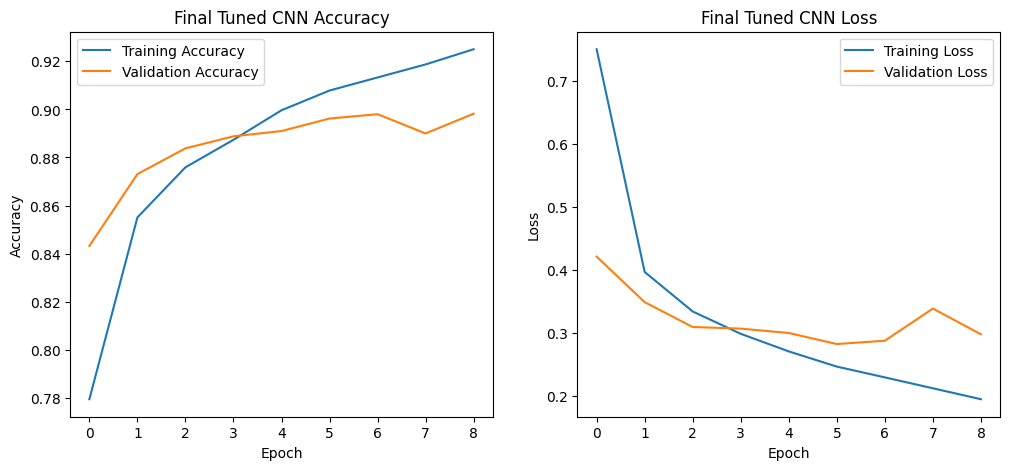

In [14]:
final_model = models.Sequential([

    layers.Conv2D(
        best_params["filters"],
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        best_params["filters"]*2,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        best_params["dense_units"],
        activation="relu"
    ),

    layers.Dropout(best_params["dropout_rate"]),

    layers.Dense(10, activation="softmax")
])

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["learning_rate"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

evaluate_model(
    final_model,
    final_history,
    "Final Tuned CNN"
)

In [15]:
final_results = pd.DataFrame(results)
final_results.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Best Validation Accuracy,Test Accuracy,Test Loss
4,Final Tuned CNN,0.8982,0.8943,0.300132
3,Experiment 3: Early Stopping,0.8982,0.8881,0.318512
2,Experiment 2: Dropout,0.8955,0.8877,0.334078
1,Experiment 1: Deeper CNN,0.8952,0.8863,0.346057
0,Baseline CNN,0.8937,0.8776,0.460286


### Optuna Tuning + Final Model Results

The best Optuna trial selected:
- 32 convolutional filters
- 128 dense units
- 0.2 dropout rate
- learning rate of approximately 0.0005

The final tuned CNN achieved the best overall performance with about **89.4%** test accuracy and the lowest test loss. Compared to the baseline CNN, the tuned model improved both validation and test performance while maintaining stable learning curves.

One important observation was that deeper CNN architectures improved performance more than the baseline model, but they also became more likely to overfit. Regularization methods such as dropout and early stopping helped reduce this issue by improving validation stability. The main tradeoff observed during model development was that larger and more complex CNNs generally performed better but required longer training times and more careful tuning.

### Personal Workflow for Building CNN Models

1. I would begin by preprocessing image data through normalization and reshaping so it can be used by convolutional layers.
2. Then I'd build a simple baseline CNN first in order to establish a reference point.
3. Perform controlled experiments by changing one factor at a time, such as adding layers, adjusting dense units, or adding dropout.
4. Track both training and validation curves to identify overfitting or underfitting.
5. Use regularization methods such as dropout and early stopping when validation performance becomes unstable.
6. Apply a systematic tuning method such as Optuna to search for stronger hyperparameter combinations.
7. Evaluate the final model on a held-out test set using both accuracy and loss rather than relying only on training accuracy.
8. Prefer models that balance strong performance with stable validation behavior rather than simply choosing the most complex architecture.

One lesson from this assignment is that deeper CNNs are effective for image classification tasks, but they can overfit if regularization is not used. Validation behavior is therefore just as important as final accuracy when selecting a model.